<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%); padding: 40px; border-radius: 10px; margin-bottom: 20px;">
<h1 style="color: white; margin: 0; font-size: 2.5em;">Lecture 12: Classical Applications</h1>
<p style="color: #888; font-size: 1.2em; margin-top: 10px;">Part IV: Applications — SCE Futures</p>
</div>

## Contents

1. [Overview: SCE Applications Landscape](#1-overview)
2. [SQUIDs and Magnetometry](#2-squids)
3. [Josephson Voltage Standards](#3-voltage-standards)
4. [Single Photon Detectors (SNSPDs)](#4-snspds)
5. [High-Speed ADCs and Digital RF](#5-adcs)
6. [Medical Imaging](#6-medical)
7. [Scientific Instruments](#7-scientific)
8. [Quantum Computing Control](#8-quantum-control)
9. [Summary](#9-summary)

In [1]:
# Setup: Import libraries for visualizations
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, FancyArrowPatch
import numpy as np

# Color scheme
COLORS = {
    'primary': '#2196F3',
    'secondary': '#FF9800',
    'success': '#4CAF50',
    'danger': '#f44336',
    'dark': '#1a1a2e',
    'light': '#f5f5f5',
    'superconducting': '#00BCD4',
    'normal': '#9E9E9E',
    'purple': '#9C27B0',
    'teal': '#009688'
}

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['font.size'] = 11

print("Setup complete.")

Setup complete.


---
<a id="1-overview"></a>
# 1. Overview: SCE Applications Landscape
---

Superconducting electronics has a rich history of practical applications, many of which are in production today. This lecture covers the **established and near-term applications** of SCE - the technologies that work now and generate real value.

### Application Maturity

| Application | Maturity | Market | Key Technology |
|-------------|----------|--------|----------------|
| **SQUIDs** | Production | $100M+/yr | DC/RF SQUID |
| **Voltage Standards** | Production | National labs | Josephson junction arrays |
| **SNSPDs** | Production | $50M+/yr | Nanowire detectors |
| **High-speed ADC** | Demonstrated | Emerging | RSFQ comparators |
| **Medical Imaging** | Production | $500M+/yr | SQUID arrays |
| **Quantum Control** | R&D | Emerging | SFQ + AQFP |

### Why These Applications?

Each application leverages a unique property of superconductors:

| Property | Enables | Applications |
|----------|---------|--------------|
| **Zero resistance** | Lossless current flow | SQUIDs, interconnects |
| **Flux quantization** | Φ₀ = 2.07 fWb exactly | Voltage standards, SQUIDs |
| **Josephson effect** | V = Φ₀ × f exactly | Voltage standards |
| **Fast switching** | ps-scale transitions | ADCs, digital logic |
| **Low noise** | Near quantum limit | SQUIDs, amplifiers |
| **Single-photon sensitivity** | Cooper pair breaking | SNSPDs |

### Comparison to AI Acceleration

| Aspect | Classical Applications | AI Acceleration |
|--------|----------------------|-----------------|
| Maturity | Production today | R&D phase |
| Scale | Small systems | Datacenter scale |
| Market | Specialized niches | Mass market potential |
| Competition | Often unique capability | Competes with GPUs |
| This lecture | ✓ Focus | → Lectures 13-14 |

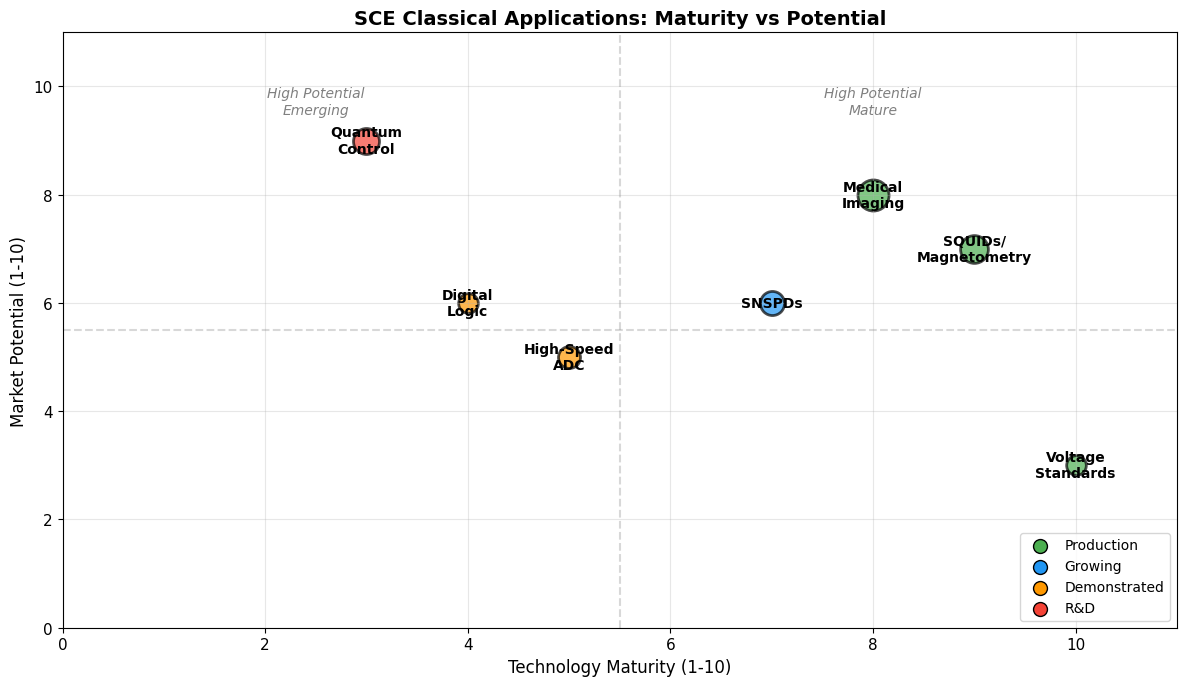

Green = Production today | Blue = Growing market | Orange = Demonstrated | Red = R&D


In [2]:
# Visualize: SCE applications by maturity and market size
fig, ax = plt.subplots(figsize=(12, 7))

applications = [
    ('SQUIDs/\nMagnetometry', 9, 7, 400, COLORS['success']),
    ('Voltage\nStandards', 10, 3, 200, COLORS['success']),
    ('SNSPDs', 7, 6, 300, COLORS['primary']),
    ('Medical\nImaging', 8, 8, 500, COLORS['success']),
    ('High-Speed\nADC', 5, 5, 250, COLORS['secondary']),
    ('Quantum\nControl', 3, 9, 350, COLORS['danger']),
    ('Digital\nLogic', 4, 6, 200, COLORS['secondary']),
]

for name, maturity, potential, size, color in applications:
    ax.scatter(maturity, potential, s=size, c=color, alpha=0.7, edgecolors='black', linewidth=2)
    ax.annotate(name, (maturity, potential), fontsize=10, ha='center', va='center', fontweight='bold')

ax.set_xlabel('Technology Maturity (1-10)', fontsize=12)
ax.set_ylabel('Market Potential (1-10)', fontsize=12)
ax.set_title('SCE Classical Applications: Maturity vs Potential', fontsize=14, fontweight='bold')
ax.set_xlim(0, 11)
ax.set_ylim(0, 11)
ax.grid(True, alpha=0.3)

# Quadrant labels
ax.axvline(x=5.5, color='gray', linestyle='--', alpha=0.3)
ax.axhline(y=5.5, color='gray', linestyle='--', alpha=0.3)
ax.text(2.5, 9.5, 'High Potential\nEmerging', fontsize=10, ha='center', style='italic', color='gray')
ax.text(8, 9.5, 'High Potential\nMature', fontsize=10, ha='center', style='italic', color='gray')

# Legend
ax.scatter([], [], s=100, c=COLORS['success'], label='Production', edgecolors='black')
ax.scatter([], [], s=100, c=COLORS['primary'], label='Growing', edgecolors='black')
ax.scatter([], [], s=100, c=COLORS['secondary'], label='Demonstrated', edgecolors='black')
ax.scatter([], [], s=100, c=COLORS['danger'], label='R&D', edgecolors='black')
ax.legend(loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

print("Green = Production today | Blue = Growing market | Orange = Demonstrated | Red = R&D")

---
<a id="2-squids"></a>
# 2. SQUIDs and Magnetometry
---

The **SQUID (Superconducting Quantum Interference Device)** is the most sensitive magnetometer ever built - and the most commercially successful SCE device.

### Operating Principle

A SQUID consists of a superconducting loop interrupted by one (RF SQUID) or two (DC SQUID) Josephson junctions:

```
DC SQUID:
                    ┌───[JJ1]───┐
     Current ──────►│           │──────► Output
                    └───[JJ2]───┘
                         │
                      Φ (flux)

The critical current is modulated by magnetic flux through the loop:
I_c(Φ) = I_c0 |cos(π Φ/Φ₀)|
```

When biased just above its critical current, the SQUID voltage is exquisitely sensitive to flux:

$$V = R \cdot \frac{\partial I_c}{\partial \Phi} \cdot \Delta\Phi$$

### SQUID Types

| Type | Junctions | Bias | Sensitivity | Complexity |
|------|-----------|------|-------------|------------|
| **DC SQUID** | 2 | DC current | ~1 µΦ₀/√Hz | Higher |
| **RF SQUID** | 1 | RF tank circuit | ~10 µΦ₀/√Hz | Lower |

DC SQUIDs are more sensitive but require more complex readout. RF SQUIDs are simpler but noisier.

### Sensitivity: The Numbers

| Metric | Value | Comparison |
|--------|-------|------------|
| Flux sensitivity | 1 µΦ₀/√Hz | 2 × 10⁻²¹ Wb/√Hz |
| Field sensitivity | 1-10 fT/√Hz | Earth's field: 50 µT |
| Energy sensitivity | ~ℏ (quantum limit) | Approaching fundamental limit |

**1 femtoTesla** = 10⁻¹⁵ T. For comparison:
- Earth's magnetic field: 50 µT (50 × 10⁻⁶ T)
- MRI machine: 1.5-7 T
- Human brain activity: 10-1000 fT
- Human heart activity: 10-100 pT

SQUIDs can detect fields **10 billion times weaker** than Earth's field.

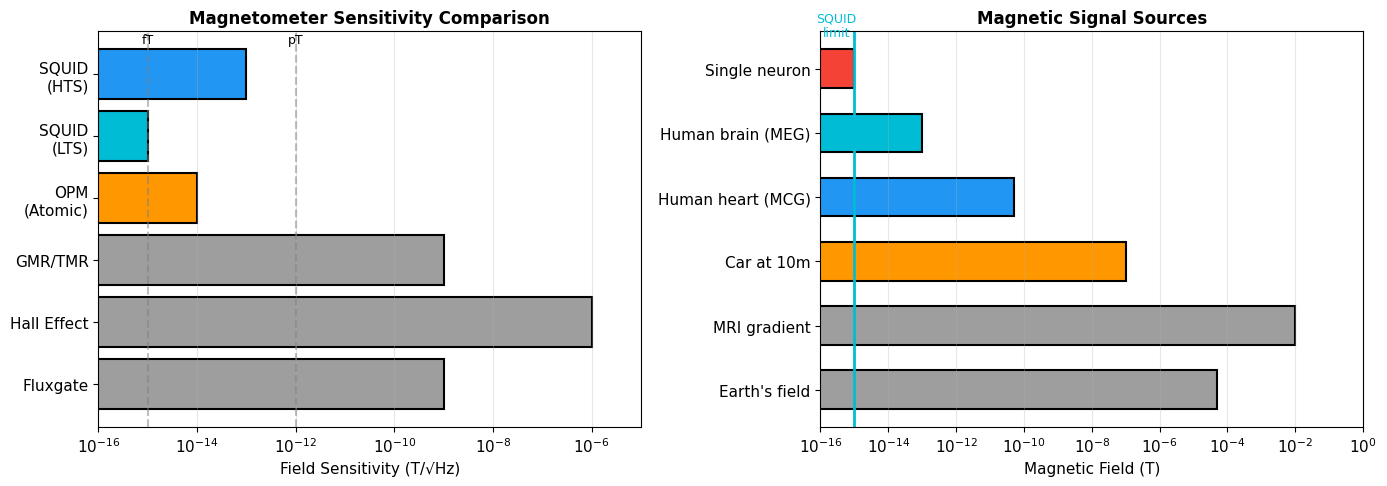

SQUIDs are 1000-1,000,000× more sensitive than competing technologies.
This enables unique applications like MEG and fundamental physics experiments.


In [3]:
# Visualize: SQUID sensitivity compared to other magnetometers
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Magnetometer sensitivity comparison
sensors = ['Fluxgate', 'Hall Effect', 'GMR/TMR', 'OPM\n(Atomic)', 'SQUID\n(LTS)', 'SQUID\n(HTS)']
sensitivity = [1e-9, 1e-6, 1e-9, 1e-14, 1e-15, 1e-13]  # T/√Hz
colors = [COLORS['normal'], COLORS['normal'], COLORS['normal'], 
          COLORS['secondary'], COLORS['superconducting'], COLORS['primary']]

bars = ax1.barh(sensors, sensitivity, color=colors, edgecolor='black', linewidth=1.5)
ax1.set_xscale('log')
ax1.set_xlabel('Field Sensitivity (T/√Hz)', fontsize=11)
ax1.set_title('Magnetometer Sensitivity Comparison', fontsize=12, fontweight='bold')
ax1.set_xlim(1e-16, 1e-5)
ax1.grid(True, alpha=0.3, axis='x')

# Reference lines
ax1.axvline(x=1e-12, color='gray', linestyle='--', alpha=0.5)
ax1.text(1e-12, 5.5, 'pT', fontsize=9, ha='center')
ax1.axvline(x=1e-15, color='gray', linestyle='--', alpha=0.5)
ax1.text(1e-15, 5.5, 'fT', fontsize=9, ha='center')

# Right: Signal sources and required sensitivity
ax2.set_title('Magnetic Signal Sources', fontsize=12, fontweight='bold')

signals = [
    ("Earth's field", 5e-5, COLORS['normal']),
    ('MRI gradient', 1e-2, COLORS['normal']),
    ('Car at 10m', 1e-7, COLORS['secondary']),
    ('Human heart (MCG)', 5e-11, COLORS['primary']),
    ('Human brain (MEG)', 1e-13, COLORS['superconducting']),
    ('Single neuron', 1e-15, COLORS['danger']),
]

for i, (name, field, color) in enumerate(signals):
    ax2.barh(i, field, color=color, edgecolor='black', linewidth=1.5, height=0.6)

ax2.set_yticks(range(len(signals)))
ax2.set_yticklabels([s[0] for s in signals])
ax2.set_xscale('log')
ax2.set_xlabel('Magnetic Field (T)', fontsize=11)
ax2.set_xlim(1e-16, 1)
ax2.grid(True, alpha=0.3, axis='x')

# SQUID detection threshold
ax2.axvline(x=1e-15, color=COLORS['superconducting'], linestyle='-', linewidth=2)
ax2.text(3e-16, 5.5, 'SQUID\nlimit', fontsize=9, ha='center', color=COLORS['superconducting'])

plt.tight_layout()
plt.show()

print("SQUIDs are 1000-1,000,000× more sensitive than competing technologies.")
print("This enables unique applications like MEG and fundamental physics experiments.")

### SQUID Applications

| Application | Field Range | Market | Key Players |
|-------------|-------------|--------|-------------|
| **Magnetoencephalography (MEG)** | 10-1000 fT | $200M/yr | Elekta, CTF, MEGIN |
| **Magnetocardiography (MCG)** | 10-100 pT | $50M/yr | CardioMag, Biomagnetik |
| **Geophysical exploration** | pT-nT | $100M/yr | SQUID systems |
| **Non-destructive testing** | nT-µT | $50M/yr | Conductus, Tristan |
| **Materials characterization** | Variable | Research | Quantum Design, MPMS |
| **Fundamental physics** | fT | Research | Universities, national labs |

### Commercial SQUID Systems

**Quantum Design MPMS** (Magnetic Property Measurement System):
- Standard tool in materials science labs worldwide
- Measures magnetic susceptibility, hysteresis, moment vs. temperature
- Sensitivity: 10⁻⁸ emu (10⁻¹¹ A·m²)
- Used in: Superconductor characterization, nanoparticle studies, thin films

**MEG Systems** (306-channel helmet arrays):
- Map brain activity with millisecond time resolution
- Clinical use: epilepsy localization, pre-surgical planning
- Research: cognitive neuroscience, brain-computer interfaces
- Cost: $2-4M per system

### SQUID Gradiometers

Most practical SQUID systems use **gradiometers** rather than magnetometers:

```
First-order gradiometer:        Second-order gradiometer:
                                
    ┌──┐  + coil                    ┌──┐  +1
    │  │                            │  │
    │  │  baseline                  ├──┤  -2
    │  │  (5-10 cm)                 │  │
    └──┘  - coil                    └──┘  +1
    
Measures: dB/dz              Measures: d²B/dz²
Rejects: uniform fields      Rejects: uniform + gradient
```

Gradiometers reject distant noise sources (power lines, Earth's field variations) while remaining sensitive to nearby sources (brain, heart, material under test).

---
<a id="3-voltage-standards"></a>
# 3. Josephson Voltage Standards
---

The **Josephson voltage standard (JVS)** is arguably the most precise measurement device ever built, and it's based entirely on superconducting electronics.

### The Josephson Effect: Voltage from Frequency

When a Josephson junction is irradiated with microwaves at frequency f, it develops **quantized voltage steps**:

$$V_n = n \cdot \frac{h}{2e} \cdot f = n \cdot \Phi_0 \cdot f$$

where:
- n = step number (integer)
- h = Planck's constant (exactly defined since 2019)
- e = elementary charge (exactly defined since 2019)
- Φ₀ = h/2e = 2.067833848... × 10⁻¹⁵ Wb (exact)

**The voltage depends only on frequency and fundamental constants - no material properties!**

### Why This Matters

Before 1990, the "volt" was defined by electrochemical cells (Weston cells) that drifted over time. Now:

| Era | Voltage Standard | Uncertainty |
|-----|-----------------|-------------|
| Pre-1972 | Weston cells | ~10⁻⁵ |
| 1972-1990 | Josephson (advisory) | ~10⁻⁸ |
| 1990-2019 | Josephson (K_J-90) | ~10⁻⁹ |
| 2019-present | Josephson (exact h, e) | **Exact definition** |

Since the 2019 SI redefinition, the Josephson effect provides the **exact realization of the volt**.

### Programmable Josephson Voltage Standards (PJVS)

Modern voltage standards use arrays of thousands of junctions:

| System | Junctions | Voltage Range | Uncertainty |
|--------|-----------|---------------|-------------|
| **NIST PJVS** | 300,000 | ±10 V | <10⁻⁹ |
| **PTB (Germany)** | 70,000 | ±1 V | <10⁻⁹ |
| **Conventional JVS** | 20,000 | 1-10 V | ~10⁻⁸ |

Each junction contributes ~70 µV per GHz of microwave frequency. To reach 10 V requires tens of thousands of junctions in series.

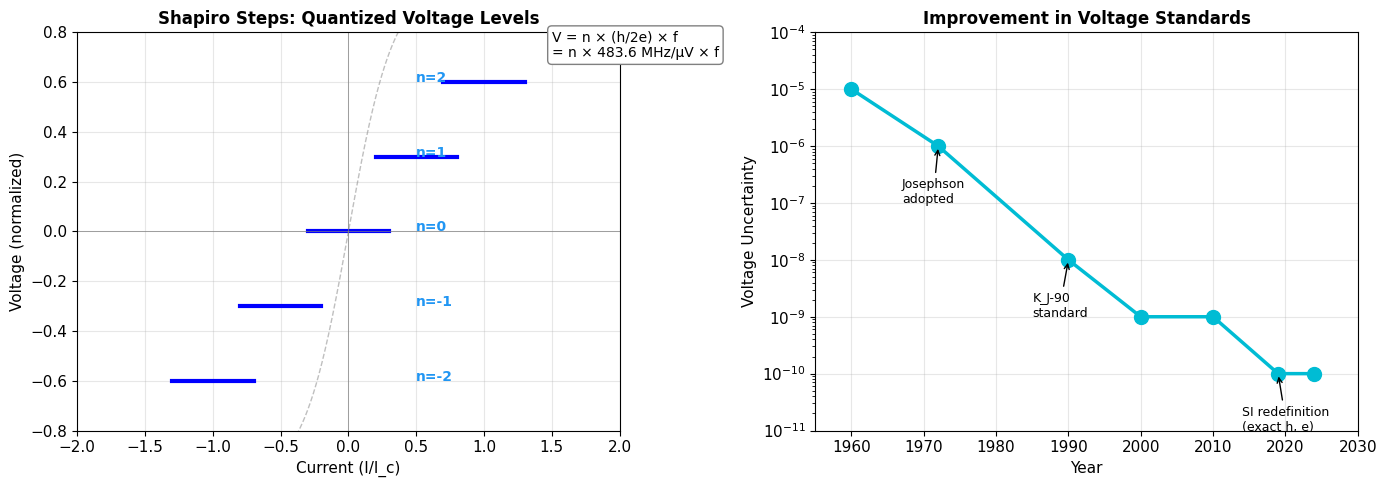

At 70 GHz, each junction contributes: 144.7 µV
For 10V output, need: 69,085 junctions


In [4]:
# Visualize: Josephson voltage standard concept
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Shapiro steps (I-V curve with microwave)
I = np.linspace(-2, 2, 1000)
V_base = np.tanh(I * 3)  # Simplified I-V

# Add Shapiro steps
step_voltage = 0.3  # Arbitrary units for visualization
for n in range(-2, 3):
    step_I = np.linspace(-0.3, 0.3, 50) + n * 0.5
    step_V = np.ones_like(step_I) * n * step_voltage
    ax1.plot(step_I, step_V, 'b-', linewidth=3)

ax1.plot(I, V_base, 'gray', linewidth=1, alpha=0.5, linestyle='--', label='No microwave')
ax1.set_xlabel('Current (I/I_c)', fontsize=11)
ax1.set_ylabel('Voltage (normalized)', fontsize=11)
ax1.set_title('Shapiro Steps: Quantized Voltage Levels', fontsize=12, fontweight='bold')
ax1.axhline(0, color='gray', linewidth=0.5)
ax1.axvline(0, color='gray', linewidth=0.5)

# Annotate steps
for n in [-2, -1, 0, 1, 2]:
    ax1.annotate(f'n={n}', xy=(0.5, n*step_voltage), fontsize=10, 
                color=COLORS['primary'], fontweight='bold')

ax1.text(1.5, 0.7, 'V = n × (h/2e) × f\n= n × 483.6 MHz/µV × f', 
        fontsize=10, bbox=dict(boxstyle='round', facecolor='white', edgecolor='gray'))
ax1.set_xlim(-2, 2)
ax1.set_ylim(-0.8, 0.8)
ax1.grid(True, alpha=0.3)

# Right: Voltage standard uncertainty over time
years = [1960, 1972, 1990, 2000, 2010, 2019, 2024]
uncertainties = [1e-5, 1e-6, 1e-8, 1e-9, 1e-9, 1e-10, 1e-10]

ax2.semilogy(years, uncertainties, 'o-', color=COLORS['superconducting'], 
            linewidth=2.5, markersize=10)
ax2.set_xlabel('Year', fontsize=11)
ax2.set_ylabel('Voltage Uncertainty', fontsize=11)
ax2.set_title('Improvement in Voltage Standards', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Annotate key events
events = [
    (1972, 1e-6, 'Josephson\nadopted'),
    (1990, 1e-8, 'K_J-90\nstandard'),
    (2019, 1e-10, 'SI redefinition\n(exact h, e)'),
]
for year, unc, label in events:
    ax2.annotate(label, xy=(year, unc), xytext=(year-5, unc*0.1),
                fontsize=9, arrowprops=dict(arrowstyle='->', color='black'))

ax2.set_xlim(1955, 2030)
ax2.set_ylim(1e-11, 1e-4)

plt.tight_layout()
plt.show()

# Calculate actual numbers
f_GHz = 70  # GHz
Phi_0 = 2.067833848e-15  # Wb
V_per_junction = Phi_0 * f_GHz * 1e9  # Volts
print(f"At {f_GHz} GHz, each junction contributes: {V_per_junction*1e6:.1f} µV")
print(f"For 10V output, need: {10 / V_per_junction:,.0f} junctions")

---
<a id="4-snspds"></a>
# 4. Single Photon Detectors (SNSPDs)
---

**Superconducting Nanowire Single-Photon Detectors (SNSPDs)** are the highest-performance single-photon detectors available, revolutionizing fields from quantum communications to deep-space optical links.

### Operating Principle

```
Nanowire (NbN, WSi, MoSi) ~100 nm wide, ~5 nm thick
Biased just below critical current

    Photon arrives
          ↓
    ┌─────●─────┐  ← Nanowire (superconducting)
    │           │
    
          ↓ photon absorbed, Cooper pairs broken
          
    ┌──▓▓▓▓▓──┐  ← Local hotspot (normal)
    │           │
    
          ↓ current diverted, voltage pulse
          
    Output: ~mV pulse, ~100 ps duration
```

1. Photon absorbed → breaks Cooper pairs → local "hotspot"
2. Current diverted around hotspot → superconductivity lost locally  
3. Normal-state resistance develops → detectable voltage pulse
4. Heat dissipates → nanowire recovers → ready for next photon

### Performance Metrics

| Metric | SNSPD (best) | APD (InGaAs) | PMT |
|--------|--------------|--------------|-----|
| **Detection efficiency** | >95% | 25% | 40% |
| **Dark count rate** | <1 Hz | 10-100 kHz | kHz |
| **Timing jitter** | <20 ps | 50-100 ps | 300 ps |
| **Recovery time** | ~10 ns | ~µs | ~10 ns |
| **Wavelength range** | UV to mid-IR | NIR | UV-NIR |
| **Operating temp** | 2-4 K | 200-300 K | 300 K |

SNSPDs dominate in every performance metric except operating temperature.

### SNSPD Applications

| Application | Wavelength | Key Benefit | Status |
|-------------|------------|-------------|--------|
| **Quantum key distribution (QKD)** | 1550 nm | Low dark counts, high efficiency | Deployed |
| **Deep-space optical comm** | 1064/1550 nm | Single-photon sensitivity | NASA DSOC |
| **LIDAR** | 1550 nm | Timing precision | R&D |
| **Fluorescence lifetime imaging** | Visible | ps timing jitter | Research |
| **Quantum computing readout** | Various | High fidelity | Growing |

### NASA DSOC: Deep Space Optical Communications

The **Deep Space Optical Communications (DSOC)** experiment on NASA's Psyche mission (launched 2023) uses SNSPDs for receiving laser signals from deep space:

- Distance: Up to 2.5 AU (Mars distance)
- Data rate: 10-100× better than RF
- Detector: 64-pixel SNSPD array
- Operating at 1 K

This demonstrates SNSPDs in a practical, high-stakes application.

### Commercial SNSPD Systems

| Vendor | Model | Efficiency | Dark Counts | Price |
|--------|-------|------------|-------------|-------|
| **ID Quantique** | ID281 | >85% | <10 Hz | ~$100K |
| **Quantum Opus** | Opus One | >90% | <1 Hz | ~$150K |
| **Photon Spot** | Various | >80% | <100 Hz | ~$80K |
| **Single Quantum** | Eos | >85% | <10 Hz | ~$100K |

The market is growing rapidly, driven by quantum communication and research applications.

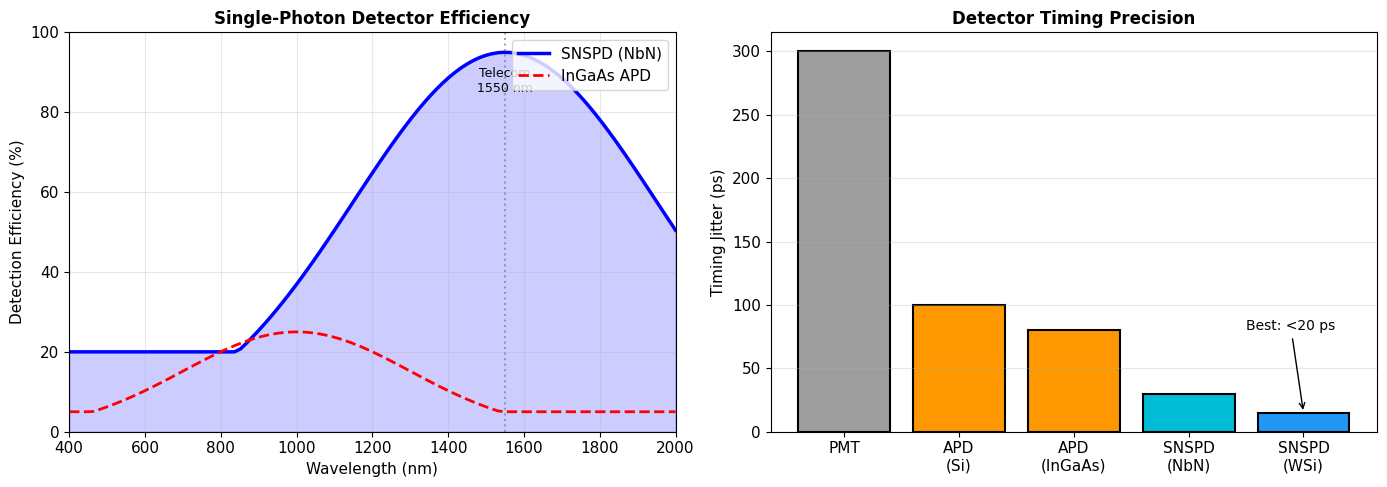

SNSPDs dominate in both efficiency (>95%) and timing precision (<20 ps).
The only drawback is the cryogenic operating temperature (1-4 K).


In [5]:
# Visualize: SNSPD performance comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Detection efficiency vs wavelength
wavelengths = np.linspace(400, 2000, 100)
# Simplified efficiency curves
snspd_eff = 95 * np.exp(-((wavelengths - 1550)**2) / (2 * 400**2))
snspd_eff = np.clip(snspd_eff, 20, 95)
apd_eff = 25 * np.exp(-((wavelengths - 1000)**2) / (2 * 300**2))
apd_eff = np.clip(apd_eff, 5, 25)

ax1.plot(wavelengths, snspd_eff, 'b-', linewidth=2.5, label='SNSPD (NbN)')
ax1.plot(wavelengths, apd_eff, 'r--', linewidth=2, label='InGaAs APD')
ax1.fill_between(wavelengths, snspd_eff, alpha=0.2, color='blue')

ax1.axvline(x=1550, color='gray', linestyle=':', alpha=0.7)
ax1.text(1550, 85, 'Telecom\n1550 nm', fontsize=9, ha='center')

ax1.set_xlabel('Wavelength (nm)', fontsize=11)
ax1.set_ylabel('Detection Efficiency (%)', fontsize=11)
ax1.set_title('Single-Photon Detector Efficiency', fontsize=12, fontweight='bold')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(400, 2000)
ax1.set_ylim(0, 100)

# Right: Timing jitter comparison
detectors = ['PMT', 'APD\n(Si)', 'APD\n(InGaAs)', 'SNSPD\n(NbN)', 'SNSPD\n(WSi)']
jitter = [300, 100, 80, 30, 15]  # ps
colors = [COLORS['normal'], COLORS['secondary'], COLORS['secondary'], 
          COLORS['superconducting'], COLORS['primary']]

bars = ax2.bar(detectors, jitter, color=colors, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Timing Jitter (ps)', fontsize=11)
ax2.set_title('Detector Timing Precision', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# Annotate best
ax2.annotate('Best: <20 ps', xy=(4, 15), xytext=(3.5, 80),
            fontsize=10, arrowprops=dict(arrowstyle='->', color='black'))

plt.tight_layout()
plt.show()

print("SNSPDs dominate in both efficiency (>95%) and timing precision (<20 ps).")
print("The only drawback is the cryogenic operating temperature (1-4 K).")

---
<a id="5-adcs"></a>
# 5. High-Speed ADCs and Digital RF
---

**Superconducting ADCs** leverage the ultra-fast switching of Josephson junctions to achieve sampling rates impossible with semiconductor technology.

### Why Superconducting ADCs?

| Advantage | Mechanism | Benefit |
|-----------|-----------|---------|
| **Ultra-fast comparators** | ps JJ switching | >50 GHz sampling |
| **Low aperture jitter** | Quantized flux | High ENOB at high frequency |
| **Low power** | ~µW per comparator | Dense integration |
| **Low noise** | Cryogenic operation | Better SNR |

### ADC Architectures

| Architecture | Speed | Resolution | SCE Implementation |
|--------------|-------|------------|-------------------|
| **Flash** | Fastest | Low (4-8 bit) | Parallel comparators |
| **Sigma-Delta** | Moderate | High (12-16 bit) | Oversampling + filtering |
| **Pipelined** | High | Medium (10-12 bit) | Staged conversion |
| **SAR** | Moderate | High | Sequential approximation |

### Demonstrated Performance

| Project | Sample Rate | Resolution | Year | Notes |
|---------|-------------|------------|------|-------|
| **HYPRES/Northrop** | 20 GS/s | 8-bit ENOB | 2010s | RSFQ-based |
| **NIST** | 10 GS/s | 10-bit ENOB | 2015 | Sigma-delta |
| **Yokohama** | 5 GS/s | 6-bit | 2020 | AQFP comparator |

### Digital RF Receivers

The "holy grail" application: **directly digitizing RF signals** without analog downconversion.

```
Traditional RF receiver:
  Antenna → LNA → Mixer → IF Filter → ADC → DSP
                    ↑
               Local Oscillator

Superconducting digital RF:
  Antenna → LNA → SCE ADC → Digital Processing
                    ↑
            Direct digitization at GHz
```

Benefits:
- Eliminate analog components (mixers, filters, LOs)
- Software-defined radio becomes truly digital
- Wideband operation without tuning
- Ideal for: radar, communications, spectrum monitoring

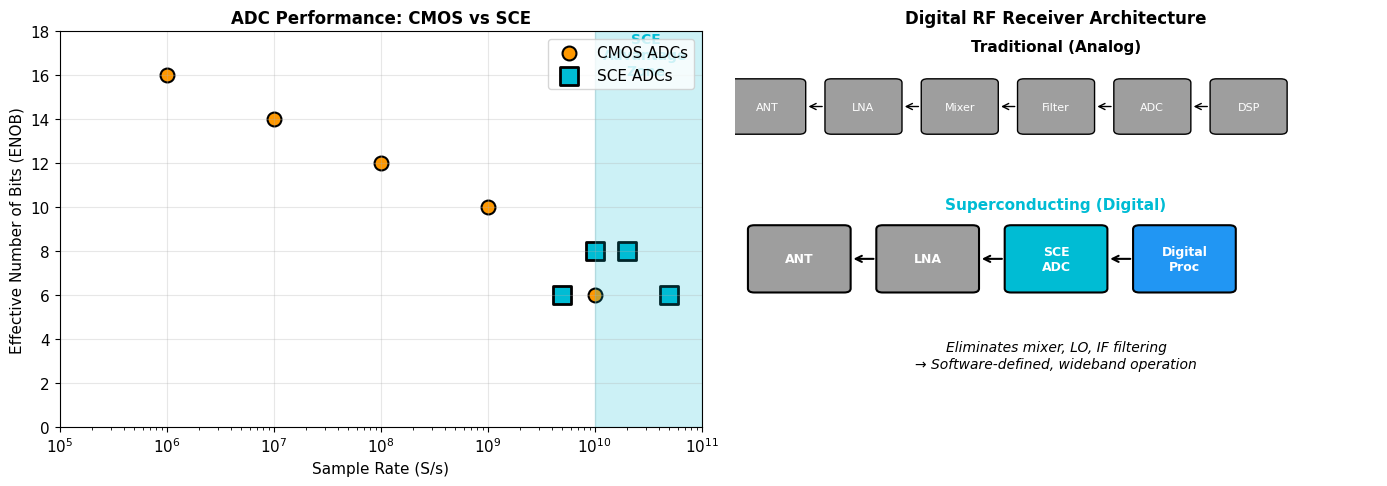

SCE ADCs enable direct RF digitization at rates impossible with CMOS.
Applications: radar, communications, spectrum monitoring, radio astronomy.


In [6]:
# Visualize: ADC performance comparison (Walden chart style)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Sample rate vs resolution (simplified Walden chart)
# CMOS ADCs
cmos_rates = [1e6, 10e6, 100e6, 1e9, 10e9]  # Sample rate
cmos_enob = [16, 14, 12, 10, 6]  # Effective bits

# SCE ADCs (demonstrated/projected)
sce_rates = [5e9, 10e9, 20e9, 50e9]
sce_enob = [6, 8, 8, 6]

ax1.scatter(cmos_rates, cmos_enob, s=100, c=COLORS['secondary'], 
           label='CMOS ADCs', edgecolors='black', linewidth=1.5)
ax1.scatter(sce_rates, sce_enob, s=150, c=COLORS['superconducting'], 
           label='SCE ADCs', edgecolors='black', linewidth=2, marker='s')

ax1.set_xscale('log')
ax1.set_xlabel('Sample Rate (S/s)', fontsize=11)
ax1.set_ylabel('Effective Number of Bits (ENOB)', fontsize=11)
ax1.set_title('ADC Performance: CMOS vs SCE', fontsize=12, fontweight='bold')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(1e5, 1e11)
ax1.set_ylim(0, 18)

# Highlight SCE advantage region
ax1.axvspan(10e9, 100e9, alpha=0.2, color=COLORS['superconducting'])
ax1.text(30e9, 16, 'SCE\nAdvantage\nZone', fontsize=10, ha='center', 
        color=COLORS['superconducting'], fontweight='bold')

# Right: Digital RF concept
ax2.set_title('Digital RF Receiver Architecture', fontsize=12, fontweight='bold')
ax2.axis('off')

# Traditional
ax2.text(0.5, 0.95, 'Traditional (Analog)', fontsize=11, ha='center', 
        fontweight='bold', transform=ax2.transAxes)
trad_blocks = [('ANT', 0.05), ('LNA', 0.2), ('Mixer', 0.35), ('Filter', 0.5), 
               ('ADC', 0.65), ('DSP', 0.8)]
for name, x in trad_blocks:
    rect = FancyBboxPatch((x-0.05, 0.75), 0.1, 0.12, boxstyle="round,pad=0.01",
                          facecolor=COLORS['normal'], edgecolor='black', 
                          linewidth=1, transform=ax2.transAxes)
    ax2.add_patch(rect)
    ax2.text(x, 0.81, name, fontsize=8, ha='center', va='center', 
            transform=ax2.transAxes, color='white')
    if x < 0.8:
        ax2.annotate('', xy=(x+0.06, 0.81), xytext=(x+0.09, 0.81),
                    arrowprops=dict(arrowstyle='->', color='black', lw=1),
                    transform=ax2.transAxes)

# SCE Digital RF
ax2.text(0.5, 0.55, 'Superconducting (Digital)', fontsize=11, ha='center', 
        fontweight='bold', color=COLORS['superconducting'], transform=ax2.transAxes)
sce_blocks = [('ANT', 0.1, COLORS['normal']), ('LNA', 0.3, COLORS['normal']), 
              ('SCE\nADC', 0.5, COLORS['superconducting']), ('Digital\nProc', 0.7, COLORS['primary'])]
for name, x, color in sce_blocks:
    rect = FancyBboxPatch((x-0.07, 0.35), 0.14, 0.15, boxstyle="round,pad=0.01",
                          facecolor=color, edgecolor='black', 
                          linewidth=1.5, transform=ax2.transAxes)
    ax2.add_patch(rect)
    ax2.text(x, 0.425, name, fontsize=9, ha='center', va='center', 
            transform=ax2.transAxes, color='white', fontweight='bold')
    if x < 0.7:
        ax2.annotate('', xy=(x+0.08, 0.425), xytext=(x+0.12, 0.425),
                    arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
                    transform=ax2.transAxes)

ax2.text(0.5, 0.15, 'Eliminates mixer, LO, IF filtering\n→ Software-defined, wideband operation', 
        fontsize=10, ha='center', transform=ax2.transAxes, style='italic')

plt.tight_layout()
plt.show()

print("SCE ADCs enable direct RF digitization at rates impossible with CMOS.")
print("Applications: radar, communications, spectrum monitoring, radio astronomy.")

---
<a id="6-medical"></a>
# 6. Medical Imaging
---

Superconducting electronics enables several medical imaging modalities that are impossible or impractical with conventional technology.

### Magnetoencephalography (MEG)

**MEG** maps brain activity by detecting the tiny magnetic fields (10-1000 fT) produced by neuronal currents.

| Aspect | Details |
|--------|---------|
| **Signal source** | Ionic currents in neurons |
| **Field strength** | 10-1000 fT (10⁻¹⁴ to 10⁻¹² T) |
| **Detector** | 300+ channel SQUID array |
| **Time resolution** | ~1 ms |
| **Spatial resolution** | ~5 mm |

```
MEG System Configuration:

        ┌──────────────────────────────┐
        │     Helmet-shaped array      │
        │    ┌─────┐  ┌─────┐         │
        │    │SQUID│  │SQUID│  × 300+ │
        │    └──┬──┘  └──┬──┘         │
        │       │        │             │
        │    Gradiometer coils         │
        │       │        │             │
        │    ┌──┴────────┴──┐         │
        │    │   Patient    │         │
        │    │    Head      │         │
        │    └──────────────┘         │
        └──────────────────────────────┘
               Inside MSR
        (Magnetically Shielded Room)
```

### Clinical Applications of MEG

| Application | Use Case | Value |
|-------------|----------|-------|
| **Epilepsy localization** | Pre-surgical mapping | Identify seizure focus |
| **Tumor mapping** | Functional areas near tumors | Preserve critical function |
| **Stroke recovery** | Monitor rehabilitation | Track brain reorganization |
| **Cognitive research** | Brain function studies | Millisecond dynamics |

### Commercial MEG Systems

| Vendor | System | Channels | Installed Base |
|--------|--------|----------|----------------|
| **MEGIN (Elekta)** | TRIUX neo | 306 | ~100 worldwide |
| **CTF** | MEG | 275 | ~50 worldwide |
| **Ricoh** | MEG | 160 | ~30 (Japan) |

Market size: ~$200M/year, growing with clinical adoption.

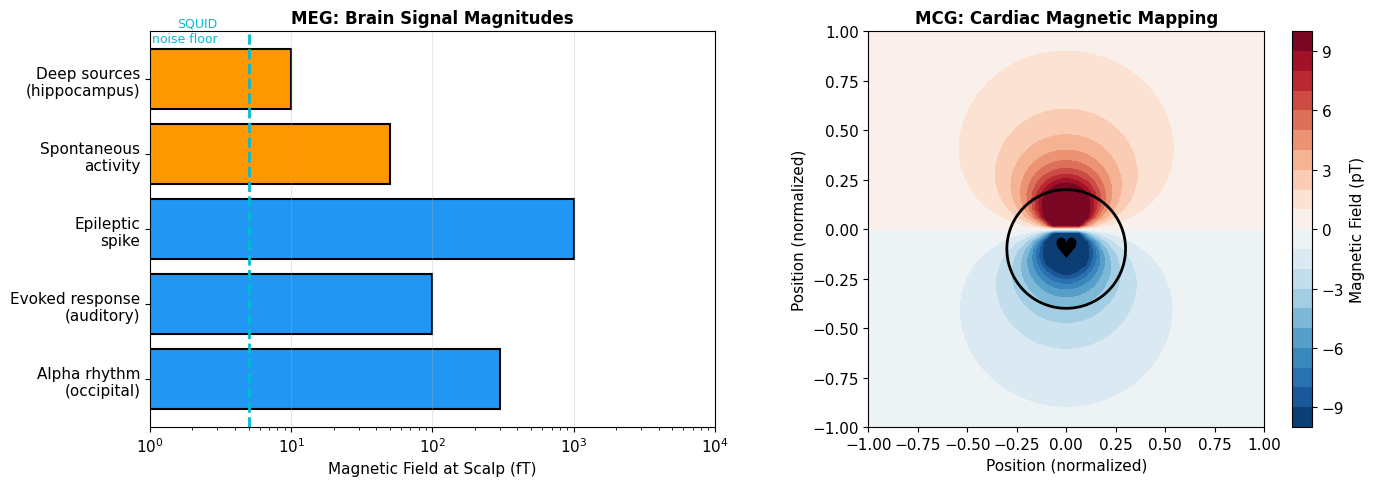

MEG: 10-1000 fT signals from brain, requires SQUID sensitivity
MCG: 10-100 pT signals from heart, can detect arrhythmias non-invasively


In [7]:
# Visualize: MEG and MCG signal ranges
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Brain signal sources and magnetic fields
sources = ['Alpha rhythm\n(occipital)', 'Evoked response\n(auditory)', 'Epileptic\nspike', 
           'Spontaneous\nactivity', 'Deep sources\n(hippocampus)']
fields = [300, 100, 1000, 50, 10]  # femtoTesla

colors = [COLORS['primary'] if f > 50 else COLORS['secondary'] for f in fields]
bars = ax1.barh(sources, fields, color=colors, edgecolor='black', linewidth=1.5)
ax1.set_xlabel('Magnetic Field at Scalp (fT)', fontsize=11)
ax1.set_title('MEG: Brain Signal Magnitudes', fontsize=12, fontweight='bold')
ax1.set_xscale('log')
ax1.set_xlim(1, 10000)
ax1.grid(True, alpha=0.3, axis='x')

# SQUID sensitivity line
ax1.axvline(x=5, color=COLORS['superconducting'], linestyle='--', linewidth=2)
ax1.text(3, 4.5, 'SQUID\nnoise floor', fontsize=9, ha='right', 
        color=COLORS['superconducting'])

# Right: MCG - heart signals
ax2.set_title('MCG: Cardiac Magnetic Mapping', fontsize=12, fontweight='bold')

# Heart magnetic field map (simplified)
x = np.linspace(-1, 1, 50)
y = np.linspace(-1, 1, 50)
X, Y = np.meshgrid(x, y)

# Dipole field pattern (simplified)
R = np.sqrt(X**2 + Y**2) + 0.1
theta = np.arctan2(Y, X)
Bz = np.sin(theta) / R**2
Bz = np.clip(Bz, -10, 10)

im = ax2.contourf(X, Y, Bz, levels=20, cmap='RdBu_r')
ax2.set_xlabel('Position (normalized)', fontsize=11)
ax2.set_ylabel('Position (normalized)', fontsize=11)
ax2.set_aspect('equal')

# Heart outline
heart_x = 0.3 * np.sin(np.linspace(0, 2*np.pi, 100))
heart_y = 0.3 * np.cos(np.linspace(0, 2*np.pi, 100))
ax2.plot(heart_x, heart_y - 0.1, 'k-', linewidth=2)
ax2.text(0, -0.1, '♥', fontsize=20, ha='center', va='center')

cbar = plt.colorbar(im, ax=ax2, label='Magnetic Field (pT)')

plt.tight_layout()
plt.show()

print("MEG: 10-1000 fT signals from brain, requires SQUID sensitivity")
print("MCG: 10-100 pT signals from heart, can detect arrhythmias non-invasively")

### Magnetocardiography (MCG)

**MCG** measures the magnetic field of the heart, complementing ECG:

| Comparison | ECG | MCG |
|------------|-----|-----|
| **Measures** | Electric potential | Magnetic field |
| **Contact** | Electrodes on skin | Non-contact |
| **Affected by** | Tissue conductivity | Not affected |
| **Spatial resolution** | Limited | Superior |
| **Equipment** | Portable, cheap | SQUID array, shielded room |

MCG advantages:
- **Non-contact**: No electrode placement issues
- **Volume conductor independent**: Not distorted by tissue
- **Better localization**: For arrhythmia source finding

### Fetal MCG

A unique application: **non-invasive fetal heart monitoring**

- Fetal ECG is contaminated by maternal signals
- Fetal MCG can be spatially separated from maternal MCG
- Enables detection of fetal arrhythmias before birth
- Critical for high-risk pregnancies

### Ultra-Low-Field MRI

Emerging application using SQUIDs instead of high-field superconducting magnets:

| Conventional MRI | ULF-MRI |
|-----------------|---------|
| 1.5-7 T field | ~µT field |
| Large SC magnet | No magnet |
| SQUID not needed | SQUID detection |
| High SNR, fast | Lower SNR, slower |
| Metal artifacts | No artifacts |
| Shielded room | Shielded room |

ULF-MRI can image near metal implants and may enable combined MEG/MRI.

---
<a id="7-scientific"></a>
# 7. Scientific Instruments
---

SCE enables scientific instruments with capabilities impossible to achieve otherwise.

### Radio Astronomy

Superconducting mixers and amplifiers are essential for radio astronomy:

| Component | Technology | Application |
|-----------|------------|-------------|
| **SIS mixers** | Nb-AlOx-Nb | mm/sub-mm receivers |
| **SQUID amplifiers** | DC SQUID | Low-noise amplification |
| **Digital spectrometers** | RSFQ | High-speed signal processing |

**ALMA (Atacama Large Millimeter Array)**:
- 66 radio telescopes in Chile
- SIS receivers for all high-frequency bands
- Superconducting mixers enable detection of faint cosmic signals

### Particle Physics

| Experiment | SCE Component | Purpose |
|------------|---------------|---------|
| **ADMX** | SQUID amplifier | Axion dark matter search |
| **Various** | TES arrays | X-ray detection |
| **CMB experiments** | TES/KID arrays | Cosmic microwave background |

### Transition Edge Sensors (TES)

**TES bolometers** operate at the superconducting transition:

```
Resistance vs Temperature:

R ↑
  │         ┌─── Normal state
  │        /
  │       /  ← Operating point
  │      /     (steep transition)
  │─────/
  │    Superconducting state
  └────────────────────────► T
         T_c

Small temperature change → Large resistance change
→ Extremely sensitive power measurement
```

Sensitivity: ~10⁻¹⁸ W (attowatt level)

Applications:
- X-ray spectroscopy (better than semiconductor detectors)
- Cosmic microwave background measurements
- Infrared astronomy

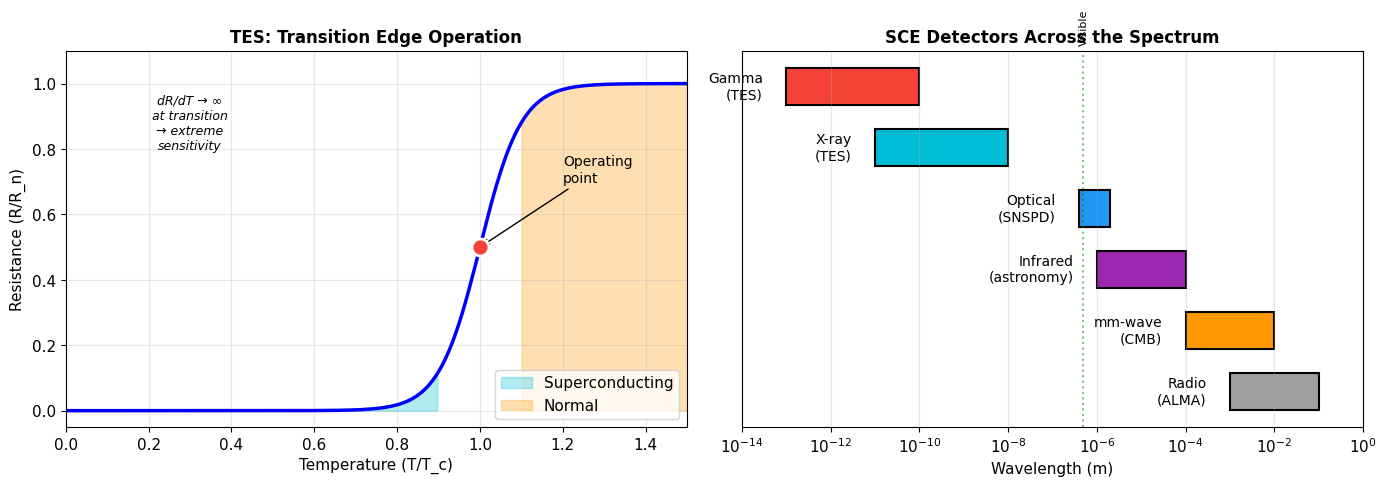

SCE detectors span from radio waves to gamma rays.
Each wavelength regime uses optimized superconducting sensor technology.


In [8]:
# Visualize: TES operating principle and scientific applications
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: TES transition curve
T = np.linspace(0, 1.5, 200)
T_c = 1.0
width = 0.05

# Sharp transition at Tc
R = 1 / (1 + np.exp(-(T - T_c) / (width)))

ax1.plot(T, R, 'b-', linewidth=2.5)
ax1.fill_between(T[T < T_c - 2*width], R[T < T_c - 2*width], alpha=0.3, 
                color=COLORS['superconducting'], label='Superconducting')
ax1.fill_between(T[T > T_c + 2*width], R[T > T_c + 2*width], alpha=0.3, 
                color=COLORS['secondary'], label='Normal')

# Operating point
op_T = T_c
op_R = 0.5
ax1.scatter([op_T], [op_R], s=150, c=COLORS['danger'], zorder=5, 
           edgecolors='white', linewidth=2)
ax1.annotate('Operating\npoint', xy=(op_T, op_R), xytext=(op_T + 0.2, op_R + 0.2),
            fontsize=10, arrowprops=dict(arrowstyle='->', color='black'))

ax1.set_xlabel('Temperature (T/T_c)', fontsize=11)
ax1.set_ylabel('Resistance (R/R_n)', fontsize=11)
ax1.set_title('TES: Transition Edge Operation', fontsize=12, fontweight='bold')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 1.5)
ax1.set_ylim(-0.05, 1.1)

# Annotation
ax1.text(0.3, 0.8, 'dR/dT → ∞\nat transition\n→ extreme\nsensitivity', 
        fontsize=9, style='italic', ha='center')

# Right: Scientific applications by wavelength
ax2.set_title('SCE Detectors Across the Spectrum', fontsize=12, fontweight='bold')

# Wavelength ranges
apps = [
    ('Radio\n(ALMA)', 1e-3, 1e-1, COLORS['normal']),
    ('mm-wave\n(CMB)', 1e-4, 1e-2, COLORS['secondary']),
    ('Infrared\n(astronomy)', 1e-6, 1e-4, COLORS['purple']),
    ('Optical\n(SNSPD)', 4e-7, 2e-6, COLORS['primary']),
    ('X-ray\n(TES)', 1e-11, 1e-8, COLORS['superconducting']),
    ('Gamma\n(TES)', 1e-13, 1e-10, COLORS['danger']),
]

for i, (name, wl_min, wl_max, color) in enumerate(apps):
    ax2.barh(i, wl_max - wl_min, left=wl_min, color=color, 
            edgecolor='black', linewidth=1.5, height=0.6)
    ax2.text(wl_min * 0.3, i, name, fontsize=10, va='center', ha='right')

ax2.set_xscale('log')
ax2.set_xlabel('Wavelength (m)', fontsize=11)
ax2.set_xlim(1e-14, 1)
ax2.set_yticks([])
ax2.grid(True, alpha=0.3, axis='x')

# Label key wavelengths
ax2.axvline(x=5e-7, color='green', linestyle=':', alpha=0.5)
ax2.text(5e-7, 5.7, 'Visible', fontsize=8, ha='center', rotation=90)

plt.tight_layout()
plt.show()

print("SCE detectors span from radio waves to gamma rays.")
print("Each wavelength regime uses optimized superconducting sensor technology.")

### Kinetic Inductance Detectors (KIDs)

**KIDs** are an alternative to TES for large detector arrays:

| Aspect | TES | KID |
|--------|-----|-----|
| **Readout** | Individual SQUID per pixel | Frequency-multiplexed |
| **Complexity** | High (wiring) | Low (single feedline) |
| **Pixels** | ~10,000 demonstrated | ~100,000 possible |
| **Sensitivity** | Higher | Slightly lower |
| **Operating T** | ~100 mK | ~100 mK |

KID principle: photon absorption changes kinetic inductance of superconductor, shifting resonator frequency.

```
KID Array Readout:
                                    
    Single microwave feedline
    ─────┬─────┬─────┬─────┬─────
         │     │     │     │
        ┌┴┐   ┌┴┐   ┌┴┐   ┌┴┐
        │1│   │2│   │3│   │4│   ← Resonators at
        └─┘   └─┘   └─┘   └─┘     different frequencies
        
    Each resonator = one pixel
    Frequency shift = absorbed power
```

Applications:
- CMB experiments (BLAST-TNG, TolTEC)
- Ground-based sub-mm astronomy
- Future space missions

### Josephson Parametric Amplifiers (JPAs)

**JPAs** provide near-quantum-limited amplification:

| Parameter | JPA | HEMT |
|-----------|-----|------|
| **Noise temperature** | ~100 mK (near quantum limit) | ~2 K |
| **Bandwidth** | ~100 MHz | GHz |
| **Gain** | 20 dB | 40 dB |
| **Operating T** | ~20 mK | 4 K |

Critical for:
- Quantum computing readout
- Axion dark matter searches
- Ultra-sensitive measurements

---
<a id="8-quantum-control"></a>
# 8. Quantum Computing Control
---

Superconducting electronics may provide the **scalability solution** for quantum computers.

### The Wiring Problem

Current quantum computers face a fundamental challenge:

```
Current approach:
                    Room Temperature (300K)
    ┌─────────────────────────────────────────┐
    │  Control electronics: AWGs, DACs, etc.  │
    │  (rack-mounted, ~kW per qubit)          │
    └───────────────────┬─────────────────────┘
                        │ Coax cables (many per qubit)
                        │ ~20 cables per qubit
    ┌───────────────────┴─────────────────────┐
    │              4K Stage                    │
    │        (just thermal anchoring)          │
    └───────────────────┬─────────────────────┘
                        │
    ┌───────────────────┴─────────────────────┐
    │             ~20 mK                       │
    │         Quantum processor                │
    │          (100s of qubits)                │
    └─────────────────────────────────────────┘
    
Problem: 1000 qubits × 20 cables = 20,000 cables!
Heat leak and physical space become impossible.
```

### SCE Solution: Control at 4K

| Approach | Temperature | Technology | Status |
|----------|-------------|------------|--------|
| **Room-temp control** | 300 K | CMOS | Current standard |
| **Cryo-CMOS** | 4 K | Si CMOS | Active R&D |
| **SCE control** | 4 K | SFQ/AQFP | Research |

SCE advantages for quantum control:
- Native 4K operation (no heating issues)
- Ultra-low power (~pW per gate)
- Fast switching (GHz rates for qubit control)
- Reduced cable count: only power and data to 300K

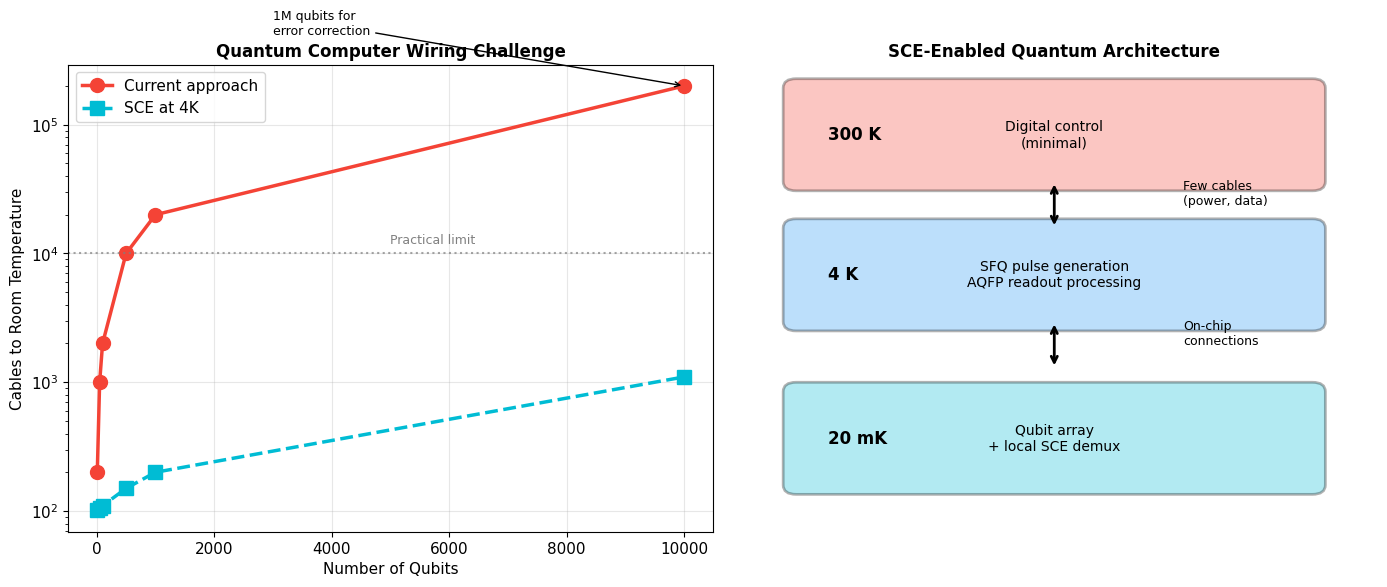

SCE at 4K could reduce cables by 100× or more.
This may be essential for scaling to 1M+ qubits.


In [9]:
# Visualize: Quantum computer wiring challenge
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left: Wiring scaling problem
qubits = np.array([10, 50, 100, 500, 1000, 10000])
cables_per_qubit = 20
total_cables = qubits * cables_per_qubit

ax1.semilogy(qubits, total_cables, 'o-', color=COLORS['danger'], 
            linewidth=2.5, markersize=10, label='Current approach')

# With SCE at 4K
sce_cables = qubits * 0.1 + 100  # Much fewer cables to room temp
ax1.semilogy(qubits, sce_cables, 's--', color=COLORS['superconducting'], 
            linewidth=2.5, markersize=10, label='SCE at 4K')

ax1.set_xlabel('Number of Qubits', fontsize=11)
ax1.set_ylabel('Cables to Room Temperature', fontsize=11)
ax1.set_title('Quantum Computer Wiring Challenge', fontsize=12, fontweight='bold')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Practical limit line
ax1.axhline(y=10000, color='gray', linestyle=':', alpha=0.7)
ax1.text(5000, 12000, 'Practical limit', fontsize=9, color='gray')

# Annotations
ax1.annotate('1M qubits for\nerror correction', xy=(10000, 200000), 
            xytext=(3000, 500000), fontsize=9,
            arrowprops=dict(arrowstyle='->', color='black'))

# Right: SCE-enabled architecture
ax2.set_title('SCE-Enabled Quantum Architecture', fontsize=12, fontweight='bold')
ax2.axis('off')

# Temperature stages
stages = [
    ('300 K', 0.85, COLORS['danger'], 'Digital control\n(minimal)'),
    ('4 K', 0.55, COLORS['primary'], 'SFQ pulse generation\nAQFP readout processing'),
    ('20 mK', 0.2, COLORS['superconducting'], 'Qubit array\n+ local SCE demux'),
]

for label, y, color, desc in stages:
    rect = FancyBboxPatch((0.1, y-0.1), 0.8, 0.2, boxstyle="round,pad=0.02",
                          facecolor=color, edgecolor='black', 
                          linewidth=2, alpha=0.3, transform=ax2.transAxes)
    ax2.add_patch(rect)
    ax2.text(0.15, y, label, fontsize=12, fontweight='bold', 
            transform=ax2.transAxes, va='center')
    ax2.text(0.5, y, desc, fontsize=10, transform=ax2.transAxes, 
            va='center', ha='center')

# Arrows showing reduced wiring
ax2.annotate('', xy=(0.5, 0.65), xytext=(0.5, 0.75),
            arrowprops=dict(arrowstyle='<->', color='black', lw=2),
            transform=ax2.transAxes)
ax2.text(0.7, 0.7, 'Few cables\n(power, data)', fontsize=9, 
        transform=ax2.transAxes)

ax2.annotate('', xy=(0.5, 0.35), xytext=(0.5, 0.45),
            arrowprops=dict(arrowstyle='<->', color='black', lw=2),
            transform=ax2.transAxes)
ax2.text(0.7, 0.4, 'On-chip\nconnections', fontsize=9, 
        transform=ax2.transAxes)

plt.tight_layout()
plt.show()

print("SCE at 4K could reduce cables by 100× or more.")
print("This may be essential for scaling to 1M+ qubits.")

### SCE Components for Quantum Control

| Function | SCE Technology | Advantage |
|----------|----------------|-----------|
| **Pulse generation** | SFQ | ps-precision timing |
| **DAC** | RSFQ/AQFP | Digital pulse shaping |
| **Multiplexing** | SFQ switches | Reduce cable count |
| **Readout** | SQUID + AQFP | Low-noise processing |
| **Classical logic** | AQFP | Error correction |

### Research Programs

| Program | Focus | Participants |
|---------|-------|--------------|
| **IARPA SuperCables** | Cryogenic interconnects | Multiple |
| **Google/UCSB** | Cryo-CMOS + SCE | Industry |
| **IBM** | Modular cryo architecture | Industry |
| **Academic** | SFQ pulse generators | Universities |

### The Vision: Fault-Tolerant Quantum Computing

Fault-tolerant quantum computing requires **millions of physical qubits** for error correction.

```
Requirement progression:

NISQ era (now):      ~100 qubits    → Room-temp control works
Near-term:           ~1,000 qubits  → Challenging but possible
Fault-tolerant:      ~1M qubits     → Requires new approach

SCE provides a path to the million-qubit scale.
```

Key metrics (targets vary by architecture):
- 100s-1000s of qubits controlled per SCE chip (architecture dependent)
- <1 µW power dissipation per qubit
- <1 ns timing precision
- >99.9% pulse fidelity

---
<a id="9-summary"></a>
# 9. Summary
---

### Classical SCE Applications at a Glance

| Application | Technology | Maturity | Key Achievement |
|-------------|------------|----------|-----------------|
| **SQUIDs** | DC/RF SQUID | Production | fT sensitivity |
| **Voltage Standards** | JJ arrays | Production | Exact volt definition |
| **SNSPDs** | Nanowire | Production | >95% efficiency |
| **High-speed ADC** | RSFQ | Demonstrated | 20+ GS/s |
| **MEG/MCG** | SQUID arrays | Production | Brain/heart imaging |
| **Scientific** | TES, KID, SIS | Production | Astrophysics, physics |
| **Quantum Control** | SFQ/AQFP | Research | Scalability solution |

### Why These Applications Succeed

Each successful SCE application leverages a **unique capability** that semiconductors cannot match:

| Application | Unique SCE Capability |
|-------------|----------------------|
| SQUIDs | Flux quantization → ultimate sensitivity |
| Voltage Standards | Josephson relation → exact metrology |
| SNSPDs | Cooper pair breaking → single photons |
| ADCs | ps switching → extreme speed |
| Medical Imaging | SQUID sensitivity → brain signals |
| Quantum Control | Native cryogenic + low power |

### Compared to AI Acceleration

| Aspect | Classical Apps | AI Acceleration |
|--------|----------------|-----------------|
| **Maturity** | Production today | R&D phase |
| **Market** | $500M+/year | Future potential |
| **Competition** | Often unique | Competes with GPUs |
| **Integration** | Small scale OK | Needs >1M gates |
| **Memory** | Minimal | TB-scale challenge |

Classical applications work because they:
- Require small-scale integration
- Don't need large memory
- Provide capabilities impossible otherwise

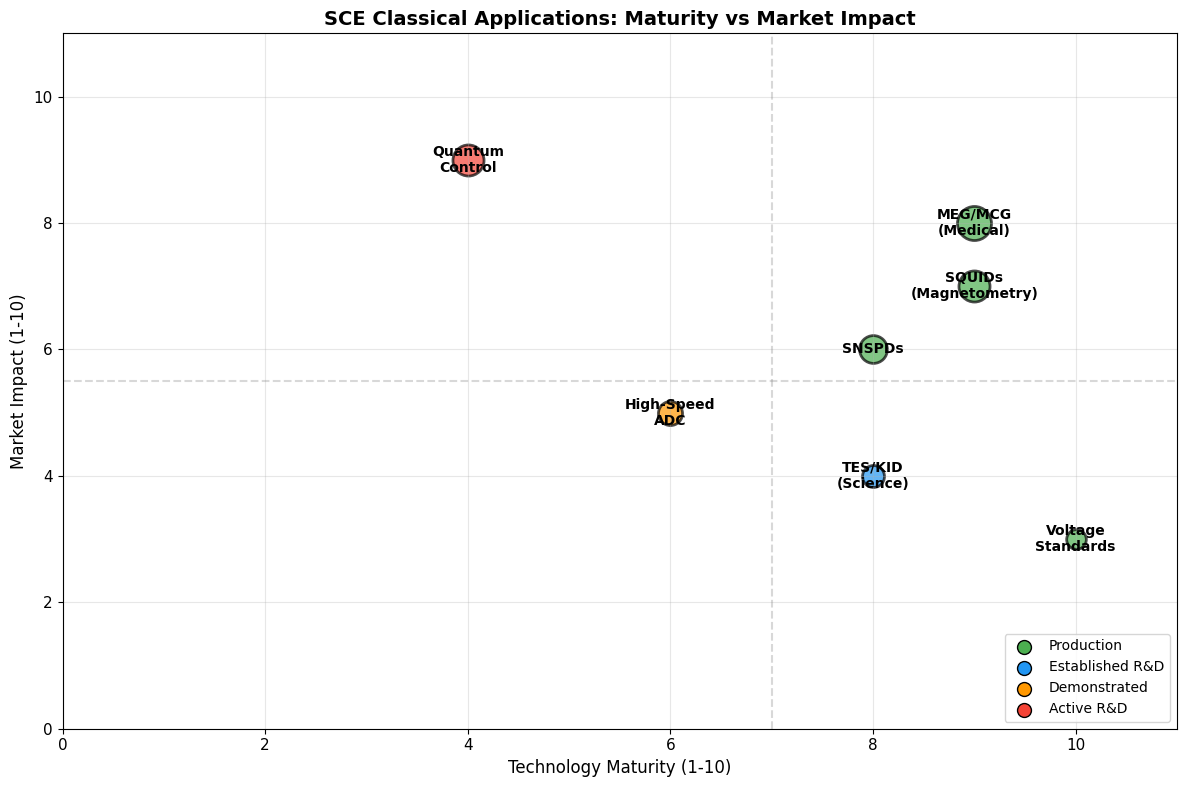


KEY TAKEAWAY
Classical SCE applications are in production TODAY, generating
$500M+/year in market value. These technologies leverage unique
superconducting properties that semiconductors cannot replicate.


In [10]:
# Visualize: Summary - SCE applications landscape
fig, ax = plt.subplots(figsize=(12, 8))
ax.set_title('SCE Classical Applications: Maturity vs Market Impact', fontsize=14, fontweight='bold')

# Applications with maturity and market size
applications = [
    ('SQUIDs\n(Magnetometry)', 9, 7, 500, COLORS['success']),
    ('Voltage\nStandards', 10, 3, 200, COLORS['success']),
    ('SNSPDs', 8, 6, 400, COLORS['success']),
    ('High-Speed\nADC', 6, 5, 300, COLORS['secondary']),
    ('MEG/MCG\n(Medical)', 9, 8, 600, COLORS['success']),
    ('TES/KID\n(Science)', 8, 4, 250, COLORS['primary']),
    ('Quantum\nControl', 4, 9, 500, COLORS['danger']),
]

for name, maturity, impact, size, color in applications:
    ax.scatter(maturity, impact, s=size, c=color, alpha=0.7, 
              edgecolors='black', linewidth=2)
    ax.annotate(name, (maturity, impact), fontsize=10, ha='center', 
               va='center', fontweight='bold')

ax.set_xlabel('Technology Maturity (1-10)', fontsize=12)
ax.set_ylabel('Market Impact (1-10)', fontsize=12)
ax.set_xlim(0, 11)
ax.set_ylim(0, 11)
ax.grid(True, alpha=0.3)

# Legend
ax.scatter([], [], s=100, c=COLORS['success'], label='Production', edgecolors='black')
ax.scatter([], [], s=100, c=COLORS['primary'], label='Established R&D', edgecolors='black')
ax.scatter([], [], s=100, c=COLORS['secondary'], label='Demonstrated', edgecolors='black')
ax.scatter([], [], s=100, c=COLORS['danger'], label='Active R&D', edgecolors='black')
ax.legend(loc='lower right', fontsize=10)

# Quadrant annotations
ax.axvline(x=7, color='gray', linestyle='--', alpha=0.3)
ax.axhline(y=5.5, color='gray', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("KEY TAKEAWAY")
print("="*60)
print("Classical SCE applications are in production TODAY, generating")
print("$500M+/year in market value. These technologies leverage unique")
print("superconducting properties that semiconductors cannot replicate.")
print("="*60)

### Key Numbers to Remember

| Parameter | Value | Context |
|-----------|-------|---------|
| SQUID sensitivity | ~1 fT/√Hz | 10 billion × better than Earth's field |
| Josephson voltage | 483.6 MHz/µV | Exact (h/2e) |
| SNSPD efficiency | >95% | Best single-photon detector |
| ADC sample rate | >20 GS/s | Direct RF digitization |
| MEG channels | 300+ | Whole-head brain imaging |
| Voltage standard uncertainty | <10⁻⁹ | Exact SI definition |

### Connections to AI Acceleration

The classical applications covered here provide the **technology foundation** for AI acceleration:

- **Fabrication**: Same Nb trilayer process
- **Testing**: SQUID-based characterization
- **I/O concepts**: Lessons from ADC, digital RF
- **Cryogenics**: Shared infrastructure
- **Control electronics**: Quantum control → AI control